In [2]:
import math
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

from enum import Enum
from itertools import product
from scipy.signal import convolve2d

img_path = "profile_pic_2020_1000x1000.png"

def find_min_max(kernel):
    min = float("inf")
    max = float("-inf")

    for row in kernel:
        for v in row:
            if v < min:
                min = v
            if v > max:
                max = v

    return (min, max)

def make_gradient(kernel):
    min, max = find_min_max(kernel)

    if min <= 0 & 0 <= max:
        center = 0
        gradient = ["#ef0044", "#ffffff", "#2aff24"]
    else:
        center = 0.5*(min+max)
        gradient = ["#ef0044", "#2aff24"]

    neg = "#0546ff"
    ctr = "#ffffff"
    pos = "#fffd07"

    if max <= 0:
        gradient = [neg, ctr]
    elif min >= 0:
        gradient = [ctr, pos]
    else:
        gradient = [neg, ctr, pos]

    norm = mcolors.TwoSlopeNorm(vmin=min, vcenter=center, vmax=max)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "custom_gradient",
        gradient
    )

    return (norm, cmap)


def plot_kernel(kernel):
    norm, cmap = make_gradient(kernel)
    plt.imshow(kernel, norm=norm, cmap=cmap)
    plt.colorbar()
    plt.show()

def apply_and_plot(kernel, img):
    kernel_ = normalize(kernel)
    img_ = normalize(img)

    out = convolve2d(img, kernel, mode='same')
    img_[:kernel_.shape[0], :kernel_.shape[1]] = kernel_

    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(img_, cmap="gray")
    axes[1].imshow(out, cmap="gray")
    plt.show()

def normalize(img):
    arr = np.array(img)
    normalized = (arr - arr.min()) / (arr.max() - arr.min())
    return normalized

(A)


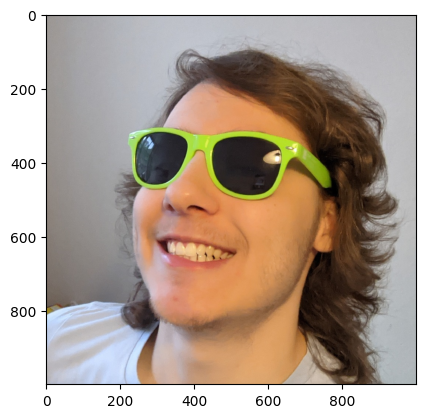

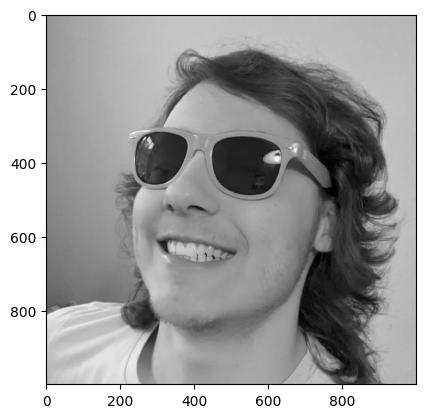

In [3]:
# Excercise 4. (A)
print("(A)")

img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

# prepare image
if img.ndim == 3:
    img = img.mean(axis=2)

plt.imshow(img, cmap="gray")
plt.show()

(B)
L: 40
v: 5


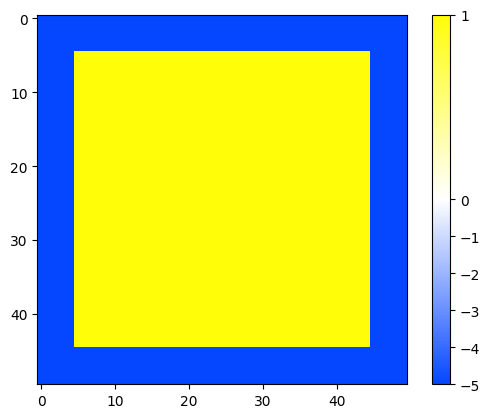

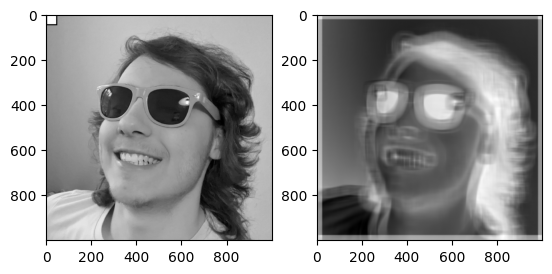

L: 25
v: 10


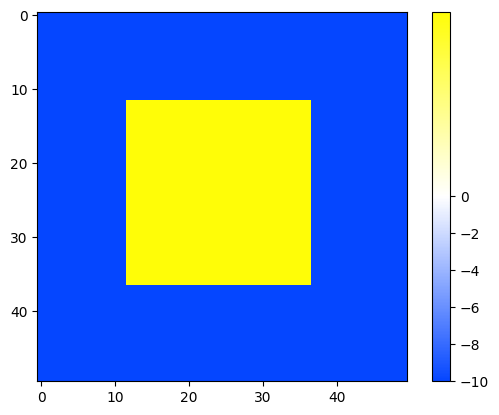

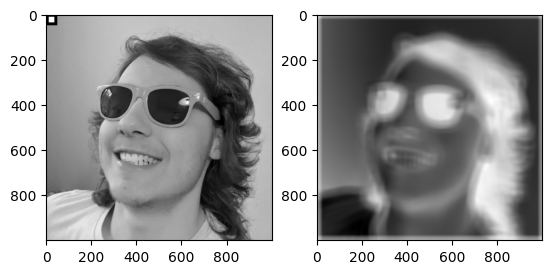

L: 25
v: -10


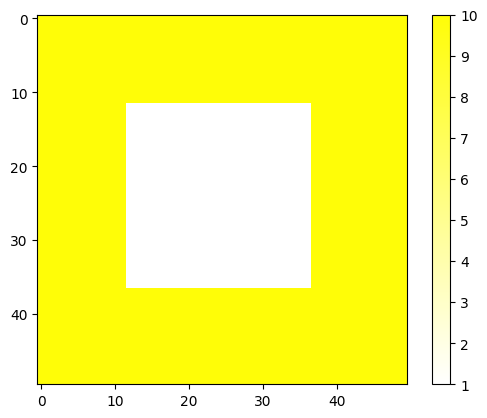

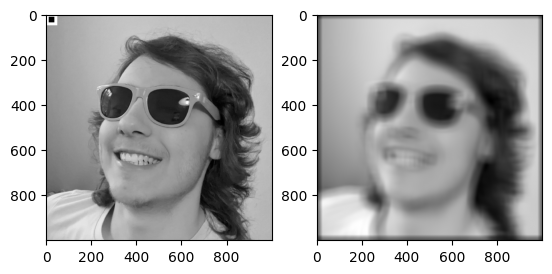

L: 2
v: 10


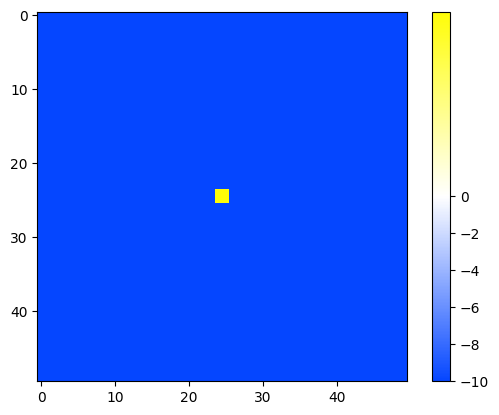

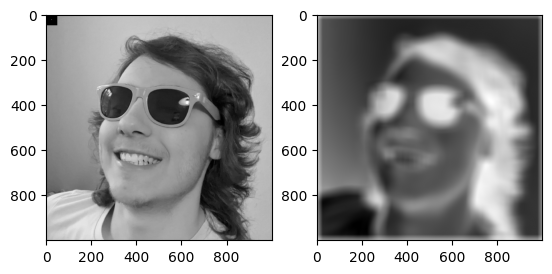

In [4]:
# Excercise 4. (B)
print("(B)")


# define helper class and function
class BoxParameter:
    def __init__(self, kernel_width, L, v):
        self.kernel_width = kernel_width
        self.L = L
        self.v = v

def make_box_kernel(kernel_width, L, v):
    kernel = np.ones((kernel_width,kernel_width)) * -v
    min = int((kernel_width - L) / 2)
    max = int((kernel_width + L) / 2)
    kernel[min:max, min:max] = 1
    return kernel

# define parameters
N = 50
box_parameters = [
    BoxParameter(N, L=40, v=5),
    BoxParameter(N, L=25, v=10),
    BoxParameter(N, L=25, v=-10),
    BoxParameter(N, L=2, v=10),
]

# generate, apply kernel and plot resulting image
for p in box_parameters:
    kernel_width = p.kernel_width
    L = p.L
    v = p.v

    print(f"L: {L}")
    print(f"v: {v}")
    
    kernel = make_box_kernel(kernel_width, L, v)
    plot_kernel(kernel)
    apply_and_plot(kernel, img)

(C)
- sigma o controls the width of the gaussian
- k controls the frequenzy of the wave
- phi controls the phase
- the gabor filter detects edges and/or parallel lines
wc: 1.1
oc: 8
ws: 1
os: 40


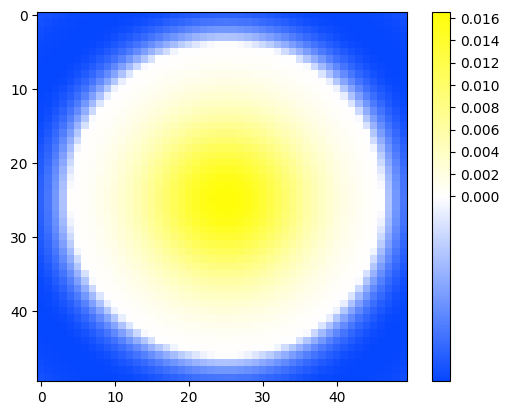

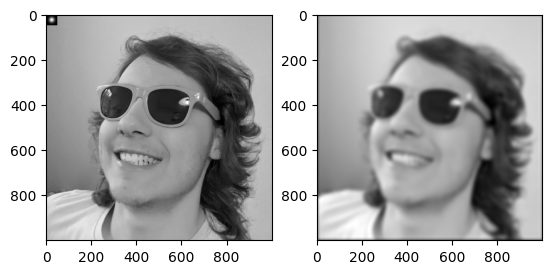

wc: 1
oc: 40
ws: 1.1
os: 8


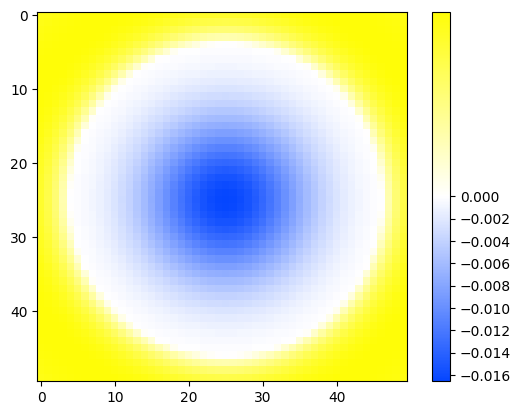

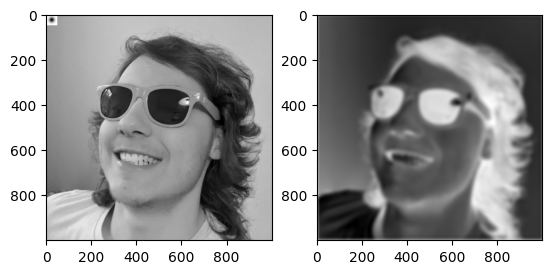

wc: 4.4
oc: 1.5
ws: 6.2
os: 5


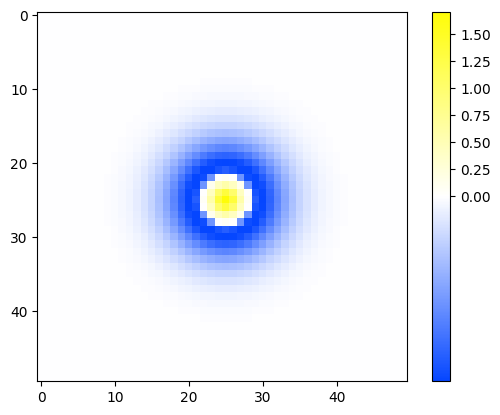

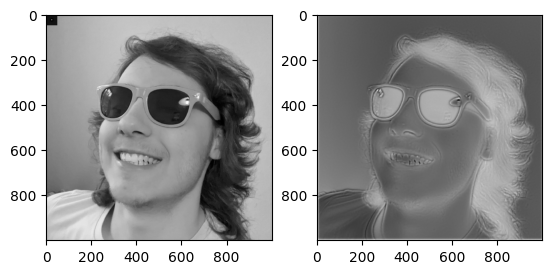

wc: 4.8
oc: 3
ws: 3.5
os: 1.8


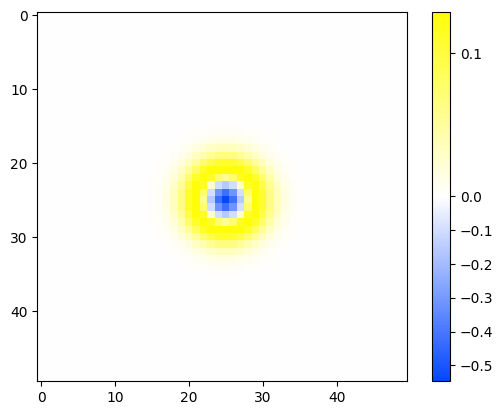

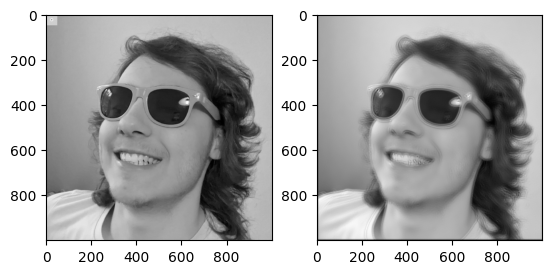

In [5]:
# Excercise 4. (C)
print("(C)")

# explanation
print("- sigma o controls the width of the gaussian")
print("- k controls the frequenzy of the wave")
print("- phi controls the phase")
print("- the gabor filter detects edges and/or parallel lines")

# define helper class and function
class GaussianParameter:
    def __init__(self, kernel_width, wc, oc, ws, os):
        self.kernel_width = kernel_width
        self.wc = wc
        self.oc = oc
        self.ws = ws
        self.os = os

# https://www.desmos.com/calculator/ytrkggiqib
def make_gaussian_kernel(p: GaussianParameter):
    kernel = np.zeros((p.kernel_width, p.kernel_width))

    for iy in range(p.kernel_width):
        for ix in range(p.kernel_width):
            x = ix - int(p.kernel_width / 2)
            y = iy - int(p.kernel_width / 2)

            x2 = x * x
            y2 = y * y
            x2y2 = x2 + y2
            wc = p.wc
            ws = p.ws
            oc = p.oc
            os = p.os
            oc2 = oc * oc
            os2 = os * os

            k1 = (wc / oc2) * math.exp(- x2y2 / (2 * oc2))
            k2 = (ws / os2) * math.exp(- x2y2 / (2 * os2))
            k = k1 - k2

            kernel[ix, iy] = k

    return kernel

# define parameters
N = 50
gaussian_parameters = [
    GaussianParameter(N, wc=1.1, oc=8, ws=1, os=40),
    GaussianParameter(N, wc=1, oc=40, ws=1.1, os=8),
    GaussianParameter(N, wc=4.4, oc=1.5, ws=6.2, os=5),
    GaussianParameter(N, wc=4.8, oc=3, ws=3.5, os=1.8),
]

# generate, apply kernel and plot resulting image
for p in gaussian_parameters:
    print(f"wc: {p.wc}")
    print(f"oc: {p.oc}")
    print(f"ws: {p.ws}")
    print(f"os: {p.os}")
    
    kernel = make_gaussian_kernel(p)
    plot_kernel(kernel)
    apply_and_plot(kernel, img)

# explanation
# sigma o controls the width of the gaussian, omega w the weight or amplitude

(D) + (E)
ox: 3.0
oy: 4.5
k: 0.2
phi: 1.5707963267948966


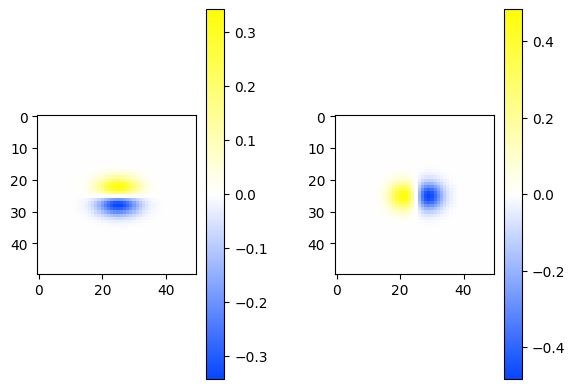

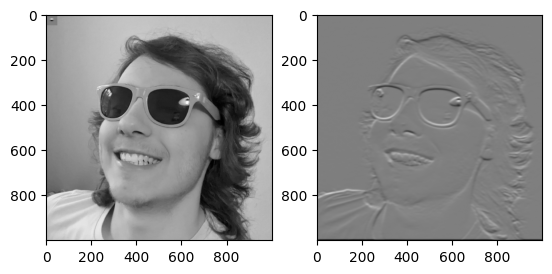

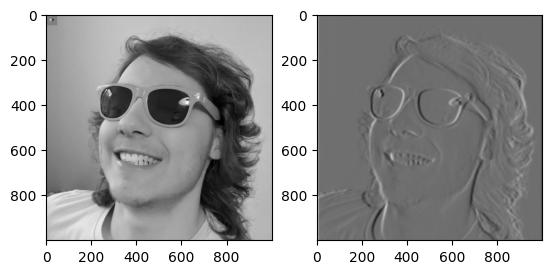

ox: 6
oy: 9
k: 0.2
phi: 3.141592653589793


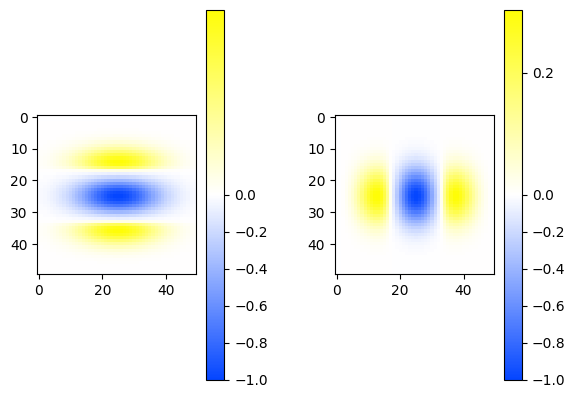

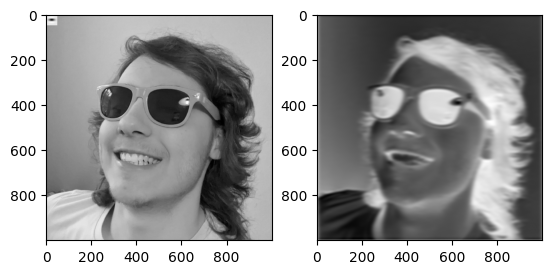

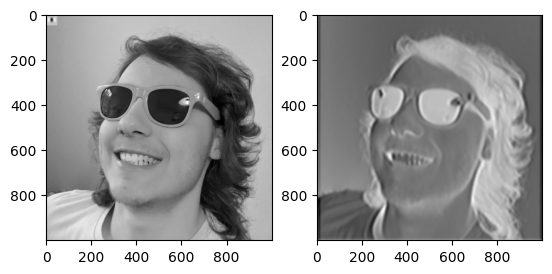

ox: 6
oy: 9
k: 0.5
phi: 0


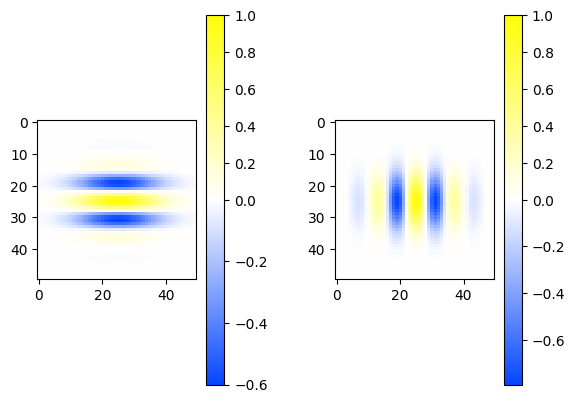

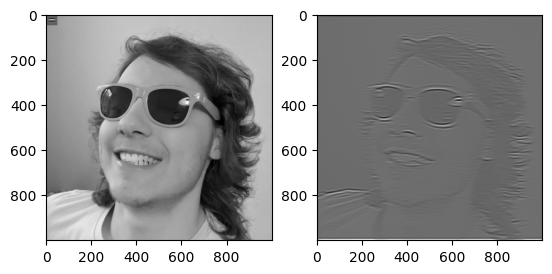

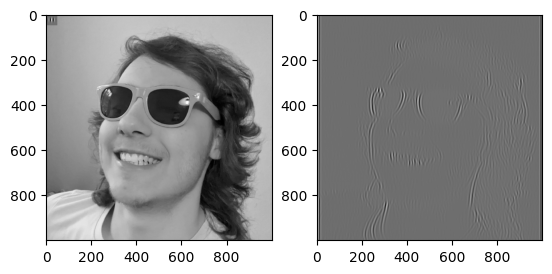

In [5]:
# Excercise 4. (D) + (E)
print("(D) + (E)")

# define helper class and function
class Orientation(Enum):
    HORIZONTAL = 1
    VERTICAL = 2

class GaborParameter:
    def __init__(
        self,
        kernel_width,
        ox,
        oy,
        k,
        phi,
    ):
        self.kernel_width = kernel_width
        self.ox = ox
        self.oy = oy
        self.k = k
        self.phi = phi

# https://www.desmos.com/calculator/qg2mdr2mqz
def make_gabor_kernel(p: GaborParameter, orientation):
    kernel = np.zeros((p.kernel_width, p.kernel_width))

    for iy in range(p.kernel_width):
        for ix in range(p.kernel_width):
            x = ix - int(p.kernel_width / 2)
            y = iy - int(p.kernel_width / 2)

            ox = p.ox
            oy = p.oy
            k = p.k
            phi = p.phi

            if orientation == Orientation.VERTICAL:
                val = x
            else:
                val = y
            
            exp = math.exp(-((x*x)/(2*ox*ox))-((y*y)/(2*oy*oy)))
            cos = math.cos(k * val + phi)
            k = exp * cos

            kernel[ix, iy] = k

    return kernel

# define parameters
gabor_parameters = [
    GaborParameter(50, ox=3.0, oy=4.5, k=0.2, phi=math.pi/2),
    GaborParameter(50, ox=6, oy=9, k=0.2, phi=math.pi),
    GaborParameter(50, ox=6, oy=9, k=0.5, phi=0),
]

# generate, apply kernel and plot resulting image
for p in gabor_parameters:
    print(f"ox: {p.ox}")
    print(f"oy: {p.oy}")
    print(f"k: {p.k}")
    print(f"phi: {p.phi}")
    
    kernel_vertical = make_gabor_kernel(p, Orientation.VERTICAL)
    kernel_horizontal = make_gabor_kernel(p, Orientation.HORIZONTAL)

    # plot kernel
    fig, axes = plt.subplots(1, 2)

    norm, cmap = make_gradient(kernel_vertical)
    im0 = axes[0].imshow(kernel_vertical, norm=norm, cmap=cmap)
    fig.colorbar(im0, ax=axes[0])

    norm, cmap = make_gradient(kernel_horizontal)
    im1 = axes[1].imshow(kernel_horizontal, norm=norm, cmap=cmap)
    fig.colorbar(im1, ax=axes[1])

    fig.subplots_adjust(wspace=0.5)

    plt.show()
    apply_and_plot(kernel_vertical, img)
    apply_and_plot(kernel_horizontal, img)

(F)


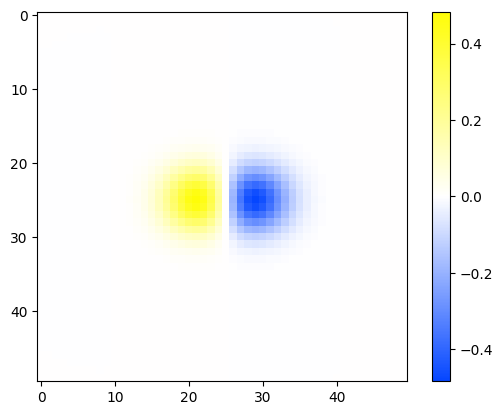

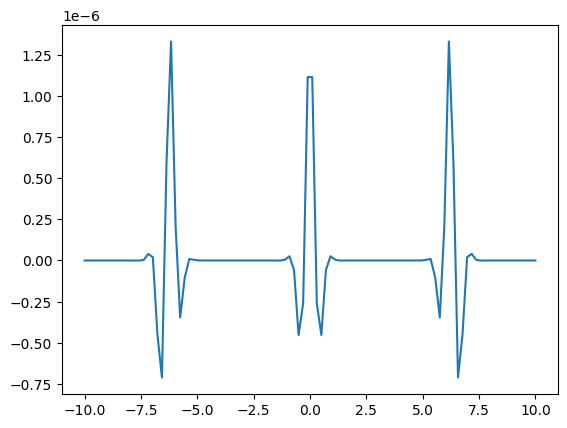

In [7]:
# Excercise 4. (F)
print("(F)")

def g_(kernel, k):
    width, height = kernel.shape
    g = 0

    for x in range(0,width):
        for y in range(0, height):
            g += kernel[x, y] * math.cos(k * x)

    return g

for p in gabor_parameters:
    kernel = make_gabor_kernel(p, orientation=Orientation.HORIZONTAL)
    plot_kernel(kernel)
    x_values = np.linspace(-10, 10, 100)

    y_values = [g_(kernel, x) for x in x_values]

    #print(f"{y_values}")

    plt.plot(x_values, y_values)
    plt.show()
    break